In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('employees.csv')

# Display the first few rows to understand the data
display(df.head())

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL,PHONE_NUMBER,HIRE_DATE,JOB_ID,SALARY,COMMISSION_PCT,MANAGER_ID,DEPARTMENT_ID
0,198,Donald,OConnell,DOCONNEL,650.507.9833,21-Jun-07,SH_CLERK,2600,-,124,50
1,199,Douglas,Grant,DGRANT,650.507.9844,13-Jan-08,SH_CLERK,2600,-,124,50
2,200,Jennifer,Whalen,JWHALEN,515.123.4444,17-Sep-03,AD_ASST,4400,-,101,10
3,201,Michael,Hartstein,MHARTSTE,515.123.5555,17-Feb-04,MK_MAN,13000,-,100,20
4,202,Pat,Fay,PFAY,603.123.6666,17-Aug-05,MK_REP,6000,-,201,20


In [2]:
# Select numeric columns for summary statistics
# In this dataset, SALARY is our primary numeric variable of interest
numeric_stats = df[['SALARY']].agg(['mean', 'median', 'min'])

print("Summary Statistics for SALARY:")
display(numeric_stats)

Summary Statistics for SALARY:


,SALARY
mean,6182.32
median,4600.00
min,2100.00


In [3]:
# Grouping by DEPARTMENT_ID and calculating summary statistics for SALARY
grouped_stats = df.groupby('DEPARTMENT_ID')['SALARY'].agg(['mean', 'median', 'min'])

print("Summary Statistics of SALARY grouped by DEPARTMENT_ID:")
display(grouped_stats)

Summary Statistics of SALARY grouped by DEPARTMENT_ID:


,mean,median,min
DEPARTMENT_ID,,,
10,4400.000000,4400.0,4400
20,9500.000000,9500.0,6000
30,4150.000000,2850.0,2500
40,6500.000000,6500.0,6500
50,3721.739130,2800.0,2100
60,5760.000000,4800.0,4200
70,10000.000000,10000.0,10000
90,19333.333333,17000.0,17000
100,8601.333333,8000.0,6900


In [4]:
# Convert the categorical variable 'JOB_ID' into numeric codes
df['JOB_ID_NUMERIC'] = df['JOB_ID'].astype('category').cat.codes

# Create a list (or dictionary mapping) of the unique responses and their numeric values
job_id_mapping = dict(enumerate(df['JOB_ID'].astype('category').cat.categories))

print("Numeric mapping for JOB_ID:")
for numeric_code, category_name in job_id_mapping.items():
    print(f"{category_name} : {numeric_code}")

print("\nFirst 5 entries showing the new numeric list representation:")
display(df[['JOB_ID', 'JOB_ID_NUMERIC']].head())

Numeric mapping for JOB_ID:
AC_ACCOUNT : 0
AC_MGR : 1
AD_ASST : 2
AD_PRES : 3
AD_VP : 4
FI_ACCOUNT : 5
FI_MGR : 6
HR_REP : 7
IT_PROG : 8
MK_MAN : 9
MK_REP : 10
PR_REP : 11
PU_CLERK : 12
PU_MAN : 13
SH_CLERK : 14
ST_CLERK : 15
ST_MAN : 16

First 5 entries showing the new numeric list representation:


,JOB_ID,JOB_ID_NUMERIC
0,SH_CLERK,14
1,SH_CLERK,14
2,AD_ASST,2
3,MK_MAN,9
4,MK_REP,10


In [5]:
# Group by JOB_ID and get the count of employees in each job role
job_id_counts = df.groupby('JOB_ID').size().reset_index(name='Count')

# Alternatively, df['JOB_ID'].value_counts() can also be used
print("Count of employees per JOB_ID:")
display(job_id_counts)

Count of employees per JOB_ID:


,JOB_ID,Count
0,AC_ACCOUNT,1
1,AC_MGR,1
2,AD_ASST,1
3,AD_PRES,1
4,AD_VP,2
5,FI_ACCOUNT,5
6,FI_MGR,1
7,HR_REP,1
8,IT_PROG,5
9,MK_MAN,1


C:\Users\hp\AppData\Local\Temp\ipykernel_16096\4158986139.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='JOB_ID', palette='viridis', order=df['JOB_ID'].value_counts().index)


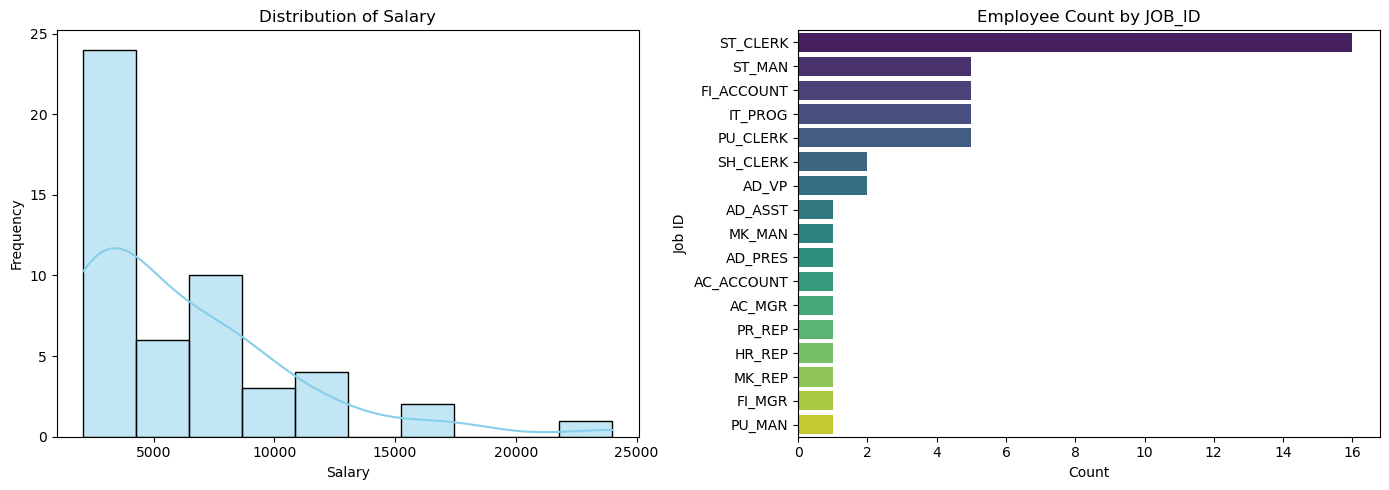

In [6]:
# Set the figure size for better readability
plt.figure(figsize=(14, 5))

# Visualization 1: Histogram of SALARY
plt.subplot(1, 2, 1)
sns.histplot(df['SALARY'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')

# Visualization 2: Bar plot of JOB_ID counts
plt.subplot(1, 2, 2)
sns.countplot(data=df, y='JOB_ID', palette='viridis', order=df['JOB_ID'].value_counts().index)
plt.title('Employee Count by JOB_ID')
plt.xlabel('Count')
plt.ylabel('Job ID')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()